In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay, distance_matrix
from scipy.linalg import solve
from abc import ABC, abstractmethod

In [3]:
class Electrode(ABC):
    def __init__(self, potential):
        self.potential = potential

    @abstractmethod
    def get_centers(self):
        pass

    @abstractmethod
    def get_areas(self):
        pass

    @abstractmethod
    def get_start_points(self, stride=1):
        pass


In [4]:
class SphereElectrode(Electrode):
    def __init__(self, center, radius, potential, n_phi=30, n_theta=20):
        super().__init__(potential)
        self.sphere = TriangulatedSphere(center, radius, n_phi, n_theta)

    def get_centers(self):
        return self.sphere.get_triangle_centers()

    def get_areas(self):
        return self.sphere.get_triangle_areas()

    def get_start_points(self, stride=5):
        centers = self.get_centers()
        return centers[::stride]

    def plot(self, ax=None, show_vertices=False, **kwargs):
        return self.sphere.plot(ax=ax, show_vertices=show_vertices, **kwargs)

    def get_points(self):
        return self.sphere.get_points()


In [5]:
class TriangulatedSphere:
    def __init__(self, center=(0, 0, 0), radius=1.0, n_phi=30, n_theta=20):
        self.center = np.array(center)
        self.radius = radius
        self.n_phi = n_phi
        self.n_theta = n_theta
        self._generate_points()
        self._compute_triangulation()
        self._compute_triangle_areas()

    def _generate_points(self):
        phi = np.linspace(0, 2 * np.pi, self.n_phi)
        theta = np.linspace(0.01, np.pi - 0.01, self.n_theta)
        self.phi, self.theta = np.meshgrid(phi, theta)

        x_unit = np.sin(self.theta) * np.cos(self.phi)
        y_unit = np.sin(self.theta) * np.sin(self.phi)
        z_unit = np.cos(self.theta)

        self.x = self.center[0] + self.radius * x_unit
        self.y = self.center[1] + self.radius * y_unit
        self.z = self.center[2] + self.radius * z_unit

        self.points = np.column_stack((self.x.ravel(), self.y.ravel(), self.z.ravel()))

    def _compute_triangulation(self):
        lon = self.phi.ravel()
        lat = self.theta.ravel()
        self.tri = Delaunay(np.column_stack((lon, lat)))
        self.simplices = self.tri.simplices
        self._compute_triangle_centers()

    def _compute_triangle_centers(self):
        centers = []
        for simplex in self.simplices:
            v0, v1, v2 = simplex
            p0 = self.points[v0]
            p1 = self.points[v1]
            p2 = self.points[v2]
            center = (p0 + p1 + p2) / 3.0
            centers.append(center)
        self.triangle_centers = np.array(centers)

    def _compute_triangle_areas(self):
        areas = []
        for simplex in self.simplices:
            v0, v1, v2 = simplex
            p0 = self.points[v0]
            p1 = self.points[v1]
            p2 = self.points[v2]
            a = p1 - p0
            b = p2 - p0
            area = 0.5 * np.linalg.norm(np.cross(a, b))
            areas.append(area)
        self.triangle_areas = np.array(areas)

    def plot(self, ax=None, show_vertices=False, **kwargs):
        if ax is None:
            fig = plt.figure(figsize=(8, 8))
            ax = fig.add_subplot(111, projection='3d')

        plot_kwargs = {
            'cmap': 'viridis',
            'edgecolor': 'k',
            'linewidth': 0.2,
            'alpha': 0.8,
            **kwargs
        }

        ax.plot_trisurf(self.x.ravel(), self.y.ravel(), self.z.ravel(),
                        triangles=self.simplices, **plot_kwargs)

        if show_vertices:
            ax.scatter(self.points[:, 0], self.points[:, 1], self.points[:, 2],
                       color='red', s=5, label='Вершины')
        return ax

    def get_points(self):
        return self.points

    def get_triangle_centers(self):
        return self.triangle_centers

    def get_triangle_areas(self):
        return self.triangle_areas


In [6]:
class SphereVisualizer:
    def __init__(self, spheres, figsize=(10, 8), **default_kwargs):
        self.spheres = spheres
        self.figsize = figsize
        self.default_kwargs = {
            'color': 'gray',
            'alpha': 0.7,
            'edgecolor': 'k',
            'linewidth': 0.2,
            **default_kwargs
        }

    def plot(self, ax=None, show_vertices=False, **kwargs):
        if ax is None:
            fig = plt.figure(figsize=self.figsize)
            ax = fig.add_subplot(111, projection='3d')

        plot_kwargs = {**self.default_kwargs, **kwargs}

        for sphere in self.spheres:
            sphere.plot(ax=ax, show_vertices=show_vertices, **plot_kwargs)

        all_points = np.vstack([s.get_points() for s in self.spheres])
        max_coord = np.max(np.abs(all_points)) * 2
        ax.set_xlim(-max_coord, max_coord)
        ax.set_ylim(-max_coord, max_coord)
        ax.set_zlim(-max_coord, max_coord)

        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')
        ax.set_title('Сферы')
        ax.set_box_aspect([1, 1, 1])
        return ax

    def show(self, **kwargs):
        ax = self.plot(**kwargs)
        plt.show()
        return ax

In [7]:
class MoMSolver:
    def __init__(self, electrodes):
        self.electrodes = electrodes
        self._build_global_arrays()

    def _build_global_arrays(self):
        centers_list = []
        areas_list = []
        potentials_list = []
        electrode_indices_list = []
        for idx, el in enumerate(self.electrodes):
            centers = el.get_centers()
            areas = el.get_areas()
            n = len(centers)
            centers_list.append(centers)
            areas_list.append(areas)
            potentials_list.extend([el.potential] * n)
            electrode_indices_list.extend([idx] * n)

        self.centers = np.vstack(centers_list)
        self.areas = np.concatenate(areas_list)
        self.potentials = np.array(potentials_list)
        self.electrode_indices = np.array(electrode_indices_list)
        self.N = len(self.centers)

    def solve_vectorized(self):
        dist = distance_matrix(self.centers, self.centers)
        np.fill_diagonal(dist, 1.0)
        A = 1.0 / dist
        np.fill_diagonal(A, 0.0)
        q = solve(A, self.potentials)
        return Solution(q, self.centers, self.electrode_indices, self.electrodes)

In [8]:
class Solution:
    def __init__(self, charges, centers, electrode_indices, electrodes):
        self.charges = charges
        self.centers = centers
        self.electrode_indices = electrode_indices
        self.electrodes = electrodes

    def total_charge_on(self, electrode):
        idx = self.electrodes.index(electrode)
        mask = (self.electrode_indices == idx)
        return np.sum(self.charges[mask])

    def capacitance(self, electrode_a, electrode_b):
        Qa = self.total_charge_on(electrode_a)
        V = abs(electrode_a.potential - electrode_b.potential)
        return abs(Qa) / V if V != 0 else 0.0


In [9]:
class FieldComputer:
    def __init__(self, solution):
        self.charges = solution.charges
        self.centers = solution.centers

    def field_at(self, point):
        r = self.centers - point
        dist = np.linalg.norm(r, axis=1)
        dist = np.where(dist < 1e-12, 1e-12, dist)
        E = np.sum(self.charges[:, np.newaxis] * r / (dist ** 3)[:, np.newaxis], axis=0)
        return E

In [10]:
class FieldLineTracer:
    def __init__(self, field_computer):
        self.field_computer = field_computer

    def trace_line(self, start_point, step=0.1, max_steps=500, direction=1):
        points = [np.array(start_point)]
        current = np.array(start_point)

        for _ in range(max_steps):
            E = self.field_computer.field_at(current)
            norm = np.linalg.norm(E)
            if norm < 1e-6:
                break
            step_vector = direction * step * E / norm
            current = current + step_vector
            points.append(current.copy())
        return points

    def trace_both_directions(self, start_point, step=0.1, max_steps=500):
        forward = self.trace_line(start_point, step, max_steps, direction=1)
        backward = self.trace_line(start_point, step, max_steps, direction=-1)
        return backward[::-1] + forward[1:]

In [11]:
class VisualizationManager:
    def __init__(self, figsize=(12, 10)):
        self.fig = plt.figure(figsize=figsize)
        self.ax = self.fig.add_subplot(111, projection='3d')
        self.elements = []

    def add_electrodes(self, electrodes, **kwargs):
        vis = SphereVisualizer(electrodes)
        vis.plot(ax=self.ax, **kwargs)
        self.elements.append(('electrodes', electrodes))

    def add_field_lines(self, tracer, start_points, step=0.1, max_steps=500, color='blue', linewidth=0.8):
        for sp in start_points:
            line = tracer.trace_both_directions(sp, step=step, max_steps=max_steps)
            xs, ys, zs = zip(*line)
            self.ax.plot(xs, ys, zs, color=color, linewidth=linewidth)
        self.elements.append(('lines',))

    def show(self):
        self.ax.set_box_aspect([1, 1, 1])
        plt.show()

In [12]:
def simple_solve_sphere(electrode):
    solver = MoMSolver([electrode])
    solution = solver.solve_vectorized()
    Q = solution.total_charge_on(electrode)
    C = Q / electrode.potential if electrode.potential else 0
    R = electrode.sphere.radius
    print(f"Ёмкость уединённой сферы: {C:.3f}. Радиус сферы: {R:.3f} ")
    field = FieldComputer(solution)
    tracer = FieldLineTracer(field)

    vis_manager = VisualizationManager()
    vis_manager.add_electrodes([electrode], color='lightgray', alpha=0.3, edgecolor='gray')

    start_points = electrode.get_start_points(stride=3)
    vis_manager.add_field_lines(tracer, start_points, step=0.1, max_steps=200, color='red', linewidth=0.8)

    vis_manager.show()


Ёмкость уединённой сферы: 2.062. Радиус сферы: 2.000 


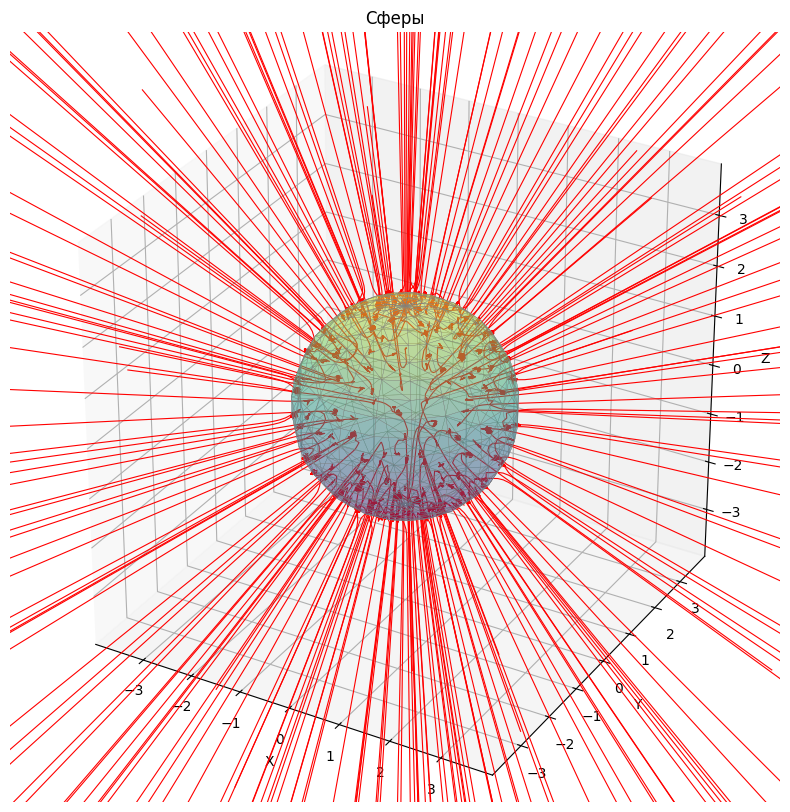

In [13]:
electrode = SphereElectrode(center=(0, 0, 0), radius=2.0, potential=1, n_phi=20, n_theta=20)
simple_solve_sphere(electrode)

In [14]:
def two_sphere_long_distance(electrode_pos, electrode_neg):
    electrodes = [electrode_pos, electrode_neg]
    solver = MoMSolver(electrodes)
    solution = solver.solve_vectorized()
    C = solution.capacitance(electrode_pos, electrode_neg)
    print(f"Ёмкость системы: {C:.3f} ")

    field = FieldComputer(solution)
    tracer = FieldLineTracer(field)

    vis_manager = VisualizationManager()
    vis_manager.add_electrodes(electrodes, color='lightgray', alpha=0.3, edgecolor='gray')

    start_points = electrode_pos.get_start_points(stride=3)
    vis_manager.add_field_lines(tracer, start_points, step=0.1, max_steps=200, color='red', linewidth=0.8)

    vis_manager.show()

Ёмкость системы: 1.150 


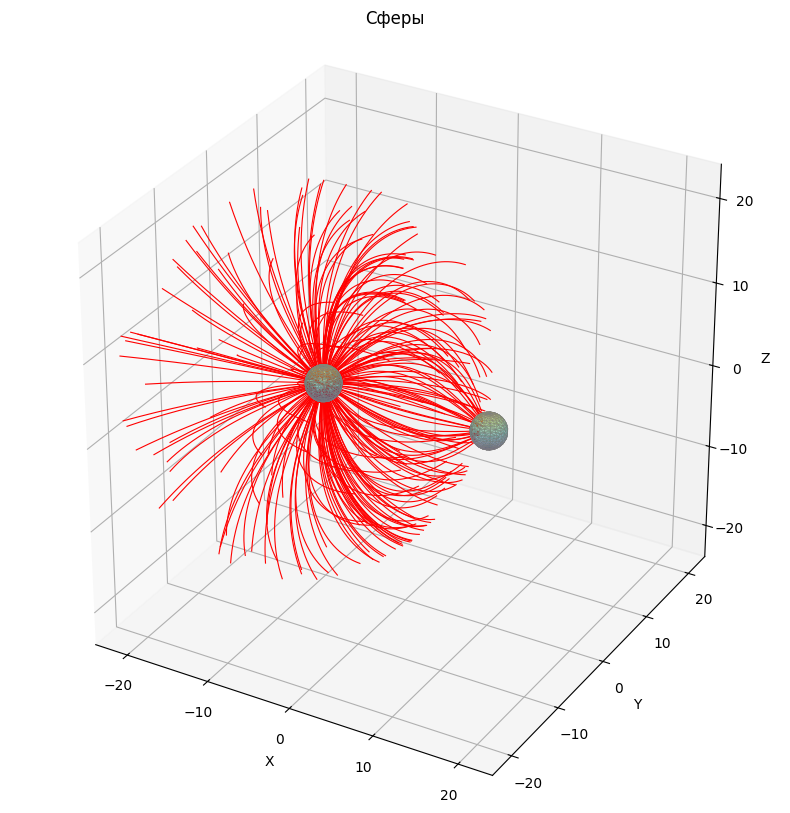

In [15]:
electrode_pos = SphereElectrode(center=(-10, 0, 0), radius=2.0, potential=1, n_phi=20, n_theta=20)
electrode_neg = SphereElectrode(center=(10, 0, 0), radius=2.0, potential=-1, n_phi=20, n_theta=20)
two_sphere_long_distance(electrode_pos, electrode_neg)

In [16]:
def concentric_spheres(electrode_inner, electrode_outer):
    electrodes = [electrode_inner, electrode_outer]
    solver = MoMSolver(electrodes)
    solution = solver.solve_vectorized()
    C_inner = solution.capacitance(electrode_inner, electrode_outer)
    C_outer = solution.capacitance(electrode_outer, electrode_inner)
    print(f"Отношение заряда внутренней сферы к разности потенциалов: {C_inner:.6f}")
    print(f"Отношение заряда внешней сферы к разности потенциалов: {C_outer:.6f}")
    
    field = FieldComputer(solution)
    tracer = FieldLineTracer(field)

    vis_manager = VisualizationManager()
    vis_manager.add_electrodes(electrodes, color='lightgray', alpha=0.3, edgecolor='gray')

    start_points = electrode_inner.get_start_points(stride=3)
    vis_manager.add_field_lines(tracer, start_points, step=0.1, max_steps=200, color='red', linewidth=0.8)

    vis_manager.show()

Отношение заряда внутренней сферы к разности потенциалов: 3.304477
Отношение заряда внешней сферы к разности потенциалов: 6.539504


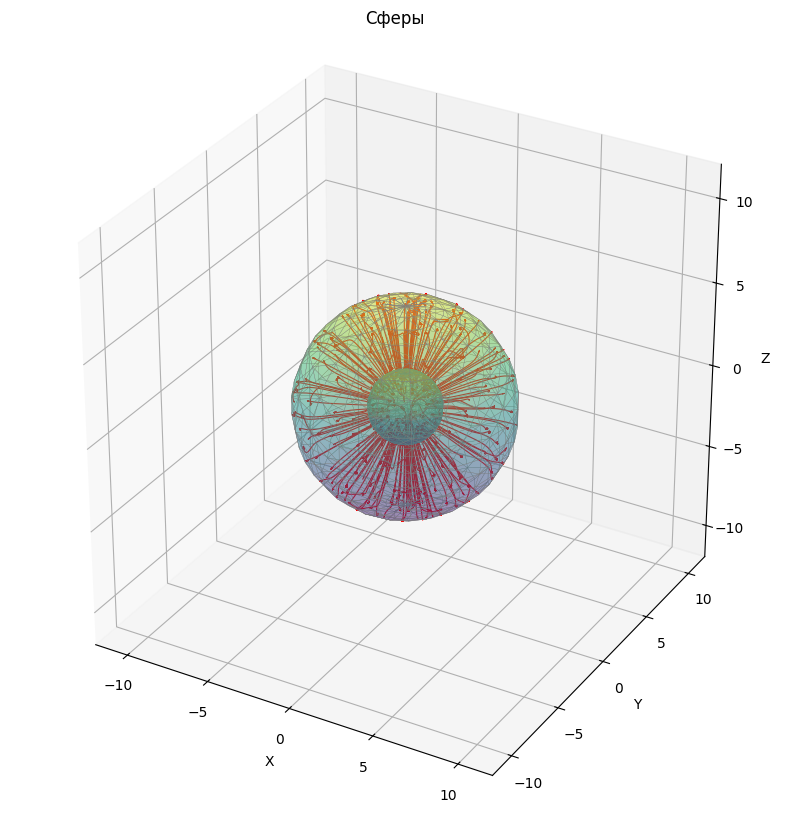

In [17]:
electrode_inner = SphereElectrode(center=(0, 0, 0), radius=2.0, potential=-1, n_phi=20, n_theta=20)
electrode_outer = SphereElectrode(center=(0, 0, 0), radius=6.0, potential=1, n_phi=20, n_theta=20)
concentric_spheres(electrode_inner, electrode_outer)

In [18]:
def compare_capacitance_concentric(R1=1.0, R2_max=10.0, num_points=20, n_phi=30, n_theta=20):
    R2_values = np.linspace(R1 * 2, R2_max, num_points)

    C_numeric = []
    C_analytic = []

    for R2 in R2_values:
        electrode_inner = SphereElectrode(center=(0, 0, 0), radius=R1, potential=1.0, n_phi=n_phi, n_theta=n_theta)
        electrode_outer = SphereElectrode(center=(0, 0, 0), radius=R2, potential=0.0, n_phi=n_phi, n_theta=n_theta)
        solver = MoMSolver([electrode_inner, electrode_outer])
        solution = solver.solve_vectorized()
        C_num = solution.capacitance(electrode_inner, electrode_outer)
        C_numeric.append(C_num)
        C_anal = (R1 * R2) / (R2 - R1)
        C_analytic.append(C_anal)

    plt.figure(figsize=(10, 6))
    plt.plot(R2_values, C_analytic, 'b-', label='Аналитическая')
    plt.plot(R2_values, C_numeric, 'ro--', label='Численная')
    plt.xlabel('Радиус внешней сферы R2')
    plt.ylabel('Ёмкость C')
    plt.title(f'Сравнение ёмкости концентрических сфер')
    plt.legend()
    plt.grid(True)
    plt.show()

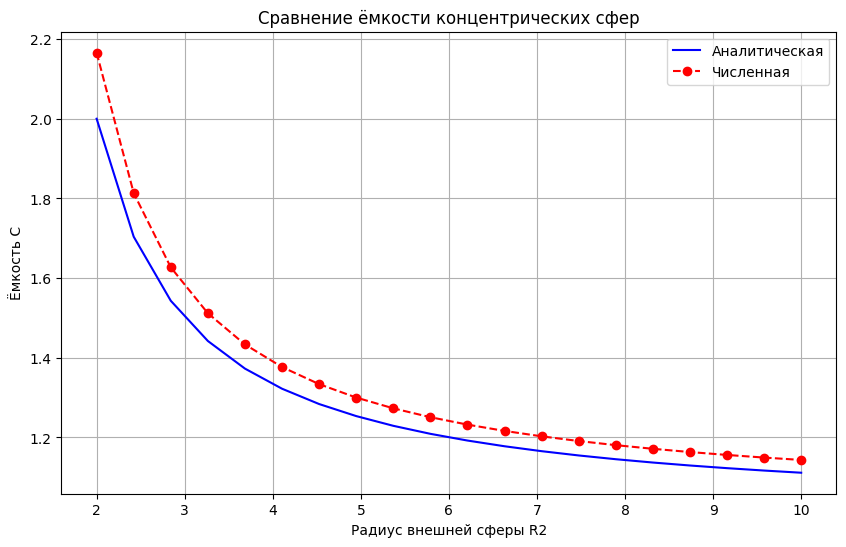

In [19]:
compare_capacitance_concentric(R1=1.0, R2_max=10.0, num_points=20, n_phi=30, n_theta=30)